In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kavanacv/group-14/Gold 100years.csv
/kaggle/input/datasets/kavanacv/group-14/Brent Oil.csv
/kaggle/input/datasets/kavanacv/group-14/silver 100 years.csv
/kaggle/input/datasets/kavanacv/group-14/swift_currency_tracker_all_reports.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset paths
brent_path = "/kaggle/input/datasets/kavanacv/group-14/Brent Oil.csv"
gold_path = "/kaggle/input/datasets/kavanacv/group-14/Gold 100years.csv"
silver_path = "/kaggle/input/datasets/kavanacv/group-14/silver 100 years.csv"
swift_path = "/kaggle/input/datasets/kavanacv/group-14/swift_currency_tracker_all_reports.csv"

# Read datasets
brent = pd.read_csv(brent_path)
gold = pd.read_csv(gold_path)
silver = pd.read_csv(silver_path)
swift = pd.read_csv(swift_path)

print("Brent:", brent.shape)
print("Gold:", gold.shape)
print("Silver:", silver.shape)
print("SWIFT:", swift.shape)

Brent: (963, 2)
Gold: (1336, 2)
Silver: (1336, 2)
SWIFT: (330, 10)


In [6]:
print("===== Brent Oil =====")
display(brent.head())

print("===== Gold =====")
display(gold.head())

print("===== Silver =====")
display(silver.head())

print("===== SWIFT =====")
display(swift.head())

===== Brent Oil =====


,Date,Value
0,01-01-1946,21.23
1,02-01-1946,21.35
2,03-01-1946,21.11
3,04-01-1946,22.79
4,05-01-1946,22.67


===== Gold =====


,Date,Value
0,01/01/1915,19.25
1,02/01/1915,19.25
2,03/01/1915,19.25
3,04/01/1915,19.25
4,05/01/1915,19.25


===== Silver =====


,Date,Value
0,01/01/1915,0.51
1,02/01/1915,0.51
2,03/01/1915,0.51
3,04/01/1915,0.51
4,05/01/1915,0.51


===== SWIFT =====


,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,NaN,Rank 1
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,NaN,Rank 2
2,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,GBP,6.73,%,NaN,Rank 3
3,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CAD,3.44,%,NaN,Rank 4
4,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,JPY,3.42,%,NaN,Rank 5


In [7]:
print("Brent Information")
brent.info()

print("\nGold Information")
gold.info()

print("\nSilver Information")
silver.info()

print("\nSWIFT Information")
swift.info()

Brent Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    963 non-null    object 
 1   Value   963 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.2+ KB

Gold Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1336 non-null   object 
 1   Value   1336 non-null   float64
dtypes: float64(1), object(1)
memory usage: 21.0+ KB

Silver Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1336 non-null   object 
 1   Value   1336 non-null   float64
dtypes: float64(1), object(1)
memory usage: 21.0+ KB

SWIFT Information
<class

In [9]:
print("Missing Values")

print("\nBrent")
print(brent.isnull().sum())

print("\nGold")
print(gold.isnull().sum())

print("\nSilver")
print(silver.isnull().sum())

print("\nSWIFT")
print(swift.isnull().sum())


Missing Values

Brent
Date     0
Value    0
dtype: int64

Gold
Date     0
Value    0
dtype: int64

Silver
Date     0
Value    0
dtype: int64

SWIFT
report_month             0
data_month               0
source_report_name       0
metric                   0
category                 0
currency_or_economy      0
value                   42
unit                    42
rmb_global_rank        280
notes                   24
dtype: int64


In [10]:
print("Duplicate Rows")

print("Brent:", brent.duplicated().sum())
print("Gold:", gold.duplicated().sum())
print("Silver:", silver.duplicated().sum())
print("SWIFT:", swift.duplicated().sum())

Duplicate Rows
Brent: 0
Gold: 0
Silver: 0
SWIFT: 0


In [11]:
# Convert Date columns to datetime format
brent['Date'] = pd.to_datetime(brent['Date'])
gold['Date'] = pd.to_datetime(gold['Date'])
silver['Date'] = pd.to_datetime(silver['Date'])

# Sort datasets by date
brent = brent.sort_values('Date')
gold = gold.sort_values('Date')
silver = silver.sort_values('Date')

print("Date conversion completed successfully!")

Date conversion completed successfully!


In [12]:
print("Brent")
print(brent.dtypes)

print("\nGold")
print(gold.dtypes)

print("\nSilver")
print(silver.dtypes)

print("\nSWIFT")
print(swift.dtypes)

Brent
Date     datetime64[ns]
Value           float64
dtype: object

Gold
Date     datetime64[ns]
Value           float64
dtype: object

Silver
Date     datetime64[ns]
Value           float64
dtype: object

SWIFT
report_month            object
data_month              object
source_report_name      object
metric                  object
category                object
currency_or_economy     object
value                  float64
unit                    object
rmb_global_rank        float64
notes                   object
dtype: object


In [13]:
print("Brent Oil Statistics")
display(brent.describe())

print("Gold Statistics")
display(gold.describe())

print("Silver Statistics")
display(silver.describe())

Brent Oil Statistics


,Date,Value
count,963,963.000000
mean,1986-01-30 14:46:43.738317760,62.709470
min,1946-01-01 00:00:00,21.110000
25%,1966-01-16 12:00:00,33.360000
50%,1986-02-01 00:00:00,50.120000
75%,2006-02-15 00:00:00,82.380000
max,2026-03-01 00:00:00,211.210000
std,NaN,35.964228


Gold Statistics


,Date,Value
count,1336,1336.000000
mean,1970-08-16 11:01:47.784431136,397.551394
min,1915-01-01 00:00:00,19.250000
25%,1942-10-24 06:00:00,35.000000
50%,1970-08-16 12:00:00,40.950000
75%,1998-06-08 12:00:00,401.075000
max,2026-04-01 00:00:00,5277.890000
std,NaN,651.394525


Silver Statistics


,Date,Value
count,1336,1336.000000
mean,1970-08-16 11:01:47.784431136,6.421755
min,1915-01-01 00:00:00,0.280000
25%,1942-10-24 06:00:00,0.720000
50%,1970-08-16 12:00:00,1.830000
75%,1998-06-08 12:00:00,6.762500
max,2026-04-01 00:00:00,113.952800
std,NaN,9.896696


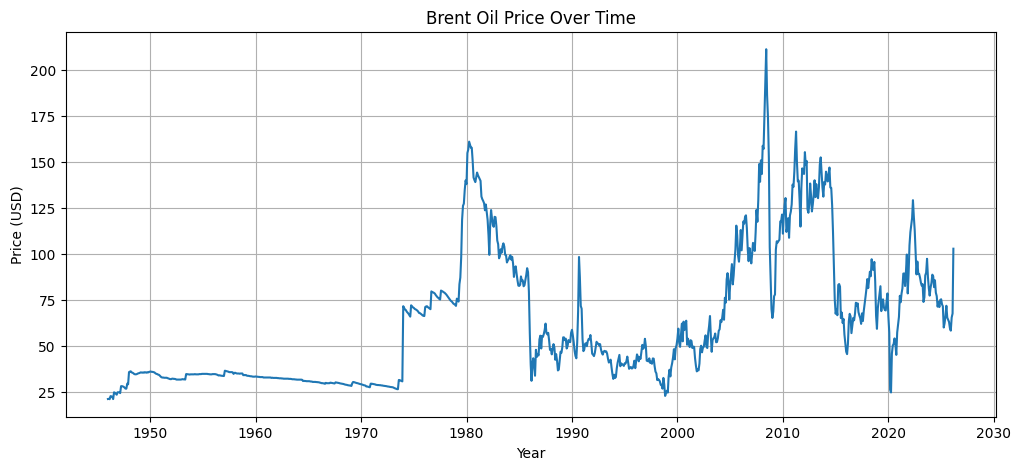

In [14]:
plt.figure(figsize=(12,5))
plt.plot(brent['Date'], brent['Value'])
plt.title("Brent Oil Price Over Time")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

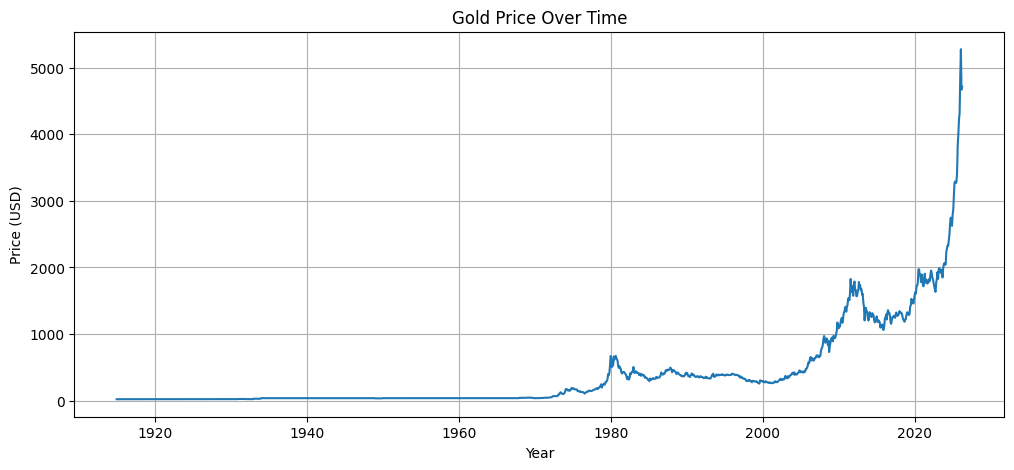

In [15]:
plt.figure(figsize=(12,5))
plt.plot(gold['Date'], gold['Value'])
plt.title("Gold Price Over Time")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [17]:
print("Brent Oil")
print("Highest Price")
display(brent.loc[brent['Value'].idxmax()])

print("Lowest Price")
display(brent.loc[brent['Value'].idxmin()])


print("\nGold")
print("Highest Price")
display(gold.loc[gold['Value'].idxmax()])

print("Lowest Price")
display(gold.loc[gold['Value'].idxmin()])


print("\nSilver")
print("Highest Price")
display(silver.loc[silver['Value'].idxmax()])

print("Lowest Price")
display(silver.loc[silver['Value'].idxmin()])

Brent Oil
Highest Price


Date     2008-06-01 00:00:00
Value                 211.21
Name: 749, dtype: object

Lowest Price


Date     1946-03-01 00:00:00
Value                  21.11
Name: 2, dtype: object


Gold
Highest Price


...

Date     1915-01-01 00:00:00
Value                  19.25
Name: 0, dtype: object


Silver
Highest Price


Date     2026-01-01 00:00:00
Value               113.9528
Name: 1332, dtype: object

Lowest Price


Date     1932-01-01 00:00:00
Value                   0.28
Name: 204, dtype: object

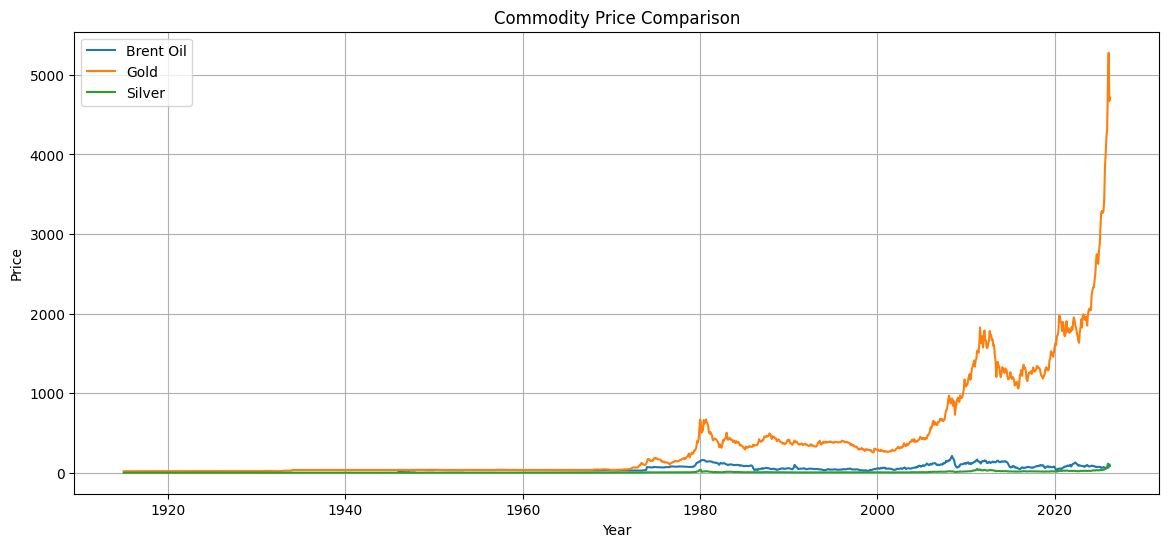

In [18]:
plt.figure(figsize=(14,6))

plt.plot(brent['Date'], brent['Value'], label='Brent Oil')
plt.plot(gold['Date'], gold['Value'], label='Gold')
plt.plot(silver['Date'], silver['Value'], label='Silver')

plt.title("Commodity Price Comparison")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
display(swift.head(10))

,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,NaN,Rank 1
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,NaN,Rank 2
2,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,GBP,6.73,%,NaN,Rank 3
3,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CAD,3.44,%,NaN,Rank 4
4,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,JPY,3.42,%,NaN,Rank 5
5,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CNY,2.73,%,6.0,Rank 6
6,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,HKD,1.68,%,NaN,Rank 7
7,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,AUD,1.60,%,NaN,Rank 8
8,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,SGD,1.33,%,NaN,Rank 9
9,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CHF,0.95,%,NaN,Rank 10


In [20]:
swift.columns

Index(['report_month', 'data_month', 'source_report_name', 'metric',
       'category', 'currency_or_economy', 'value', 'unit', 'rmb_global_rank',
       'notes'],
      dtype='object')

In [21]:
for col in swift.columns:
    print(f"\n{col}")
    print(swift[col].unique()[:20])   # first 20 unique values


report_month
['January 2026' 'February 2026' 'April 2026' 'March 2026']

data_month
['December 2025' 'January 2026' 'March 2026' 'February 2026']

source_report_name
['RMB Tracker' 'Global Currency Tracker']

metric
['Global Payment Share' 'International Payment Share (ex-Eurozone)'
 'RMB MoM Payment Growth' 'All Currencies MoM Payment Growth'
 'Offshore RMB by Economy' 'Trade Finance Share'
 'FX Spot Currency Ranking' 'FX Spot Economies (RMB)']

category
['Currency Ranking' 'RMB Activity' 'Market Activity' 'Offshore Economies'
 'FX Spot']

currency_or_economy
['USD' 'EUR' 'GBP' 'CAD' 'JPY' 'CNY' 'HKD' 'AUD' 'SGD' 'CHF' 'SEK' 'PLN'
 'NOK' 'DKK' 'NZD' 'MXN' 'ZAR' 'THB' 'HUF' 'MYR']

value
[50.49 21.9   6.73  3.44  3.42  2.73  1.68  1.6   1.33  0.95  0.73  0.72
  0.52  0.33  0.32  0.3   0.28  0.23 58.62 13.68]

unit
['%' nan]

rmb_global_rank
[nan  6.  5.  4.]

notes
['Rank 1' 'Rank 2' 'Rank 3' 'Rank 4' 'Rank 5' 'Rank 6' 'Rank 7' 'Rank 8'
 'Rank 9' 'Rank 10' 'Rank 11' 'Rank 12' 'Rank 13

In [26]:
print(swift['metric'].unique())

['Global Payment Share' 'International Payment Share (ex-Eurozone)'
 'RMB MoM Payment Growth' 'All Currencies MoM Payment Growth'
 'Offshore RMB by Economy' 'Trade Finance Share'
 'FX Spot Currency Ranking' 'FX Spot Economies (RMB)']


In [27]:
print(swift['category'].unique())

['Currency Ranking' 'RMB Activity' 'Market Activity' 'Offshore Economies'
 'FX Spot']


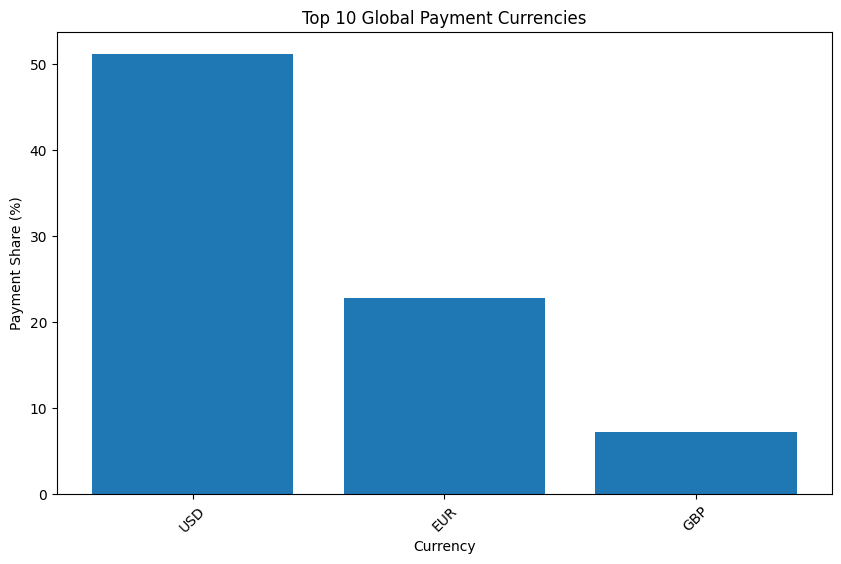

In [35]:
import matplotlib.pyplot as plt

# Select payment share data
payment_share = swift[swift['metric'] == 'Global Payment Share']

# Sort and get top 10
top10 = payment_share.sort_values('value', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['currency_or_economy'], top10['value'])

plt.title("Top 10 Global Payment Currencies")
plt.xlabel("Currency")
plt.ylabel("Payment Share (%)")
plt.xticks(rotation=45)

plt.show()

In [30]:
payment_share = swift[swift['metric'] == 'Global Payment Share']

print(payment_share.shape)

display(payment_share.head())

(80, 10)


,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,NaN,Rank 1
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,NaN,Rank 2
2,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,GBP,6.73,%,NaN,Rank 3
3,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CAD,3.44,%,NaN,Rank 4
4,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,JPY,3.42,%,NaN,Rank 5


In [32]:
display(
    top10[['currency_or_economy','value']]
)

,currency_or_economy,value
166,USD,51.14
0,USD,50.49
83,USD,49.68
248,USD,49.25
249,EUR,22.82
84,EUR,22.36
1,EUR,21.90
167,EUR,21.30
250,GBP,7.16
85,GBP,6.91


In [33]:
latest_payment = swift[
    (swift['metric'] == 'Global Payment Share') &
    (swift['report_month'] == 'January 2026')
]

latest_payment = latest_payment.sort_values('value', ascending=False)

display(latest_payment[['currency_or_economy','value']])

,currency_or_economy,value
0,USD,50.49
1,EUR,21.90
2,GBP,6.73
3,CAD,3.44
4,JPY,3.42
5,CNY,2.73
6,HKD,1.68
7,AUD,1.60
8,SGD,1.33
9,CHF,0.95


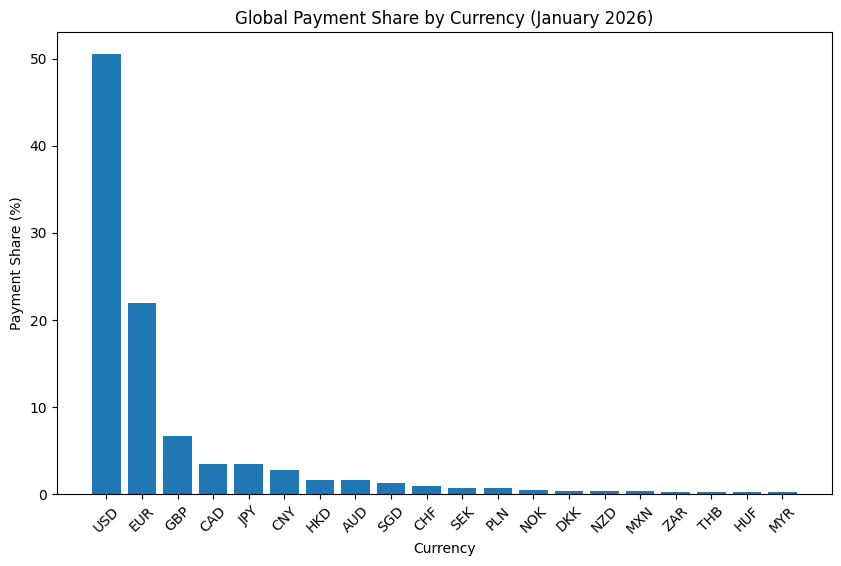

In [36]:
plt.figure(figsize=(10,6))

plt.bar(
    latest_payment['currency_or_economy'],
    latest_payment['value']
)

plt.title("Global Payment Share by Currency (January 2026)")
plt.xlabel("Currency")
plt.ylabel("Payment Share (%)")
plt.xticks(rotation=45)

plt.show()